# Tarea 1
## Mario Alejandro Castro Lerma

In [14]:
# ============================================================
# Benchmarks para Lost Explorers Optimization (LEO)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time

# ============================================================
# FUNCIONES BENCHMARK
# ============================================================


def sphere(position):
    x, y = position
    return -(x**2 + y**2)


def rastrigin(position):
    x, y = position
    
    value = (
        20
        + x**2
        + y**2
        - 10*np.cos(2*np.pi*x)
        - 10*np.cos(2*np.pi*y)
    )
    
    return -value


def ackley(position):
    x, y = position
    
    value = (
        -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
        - np.exp(0.5 * (
            np.cos(2*np.pi*x)
            + np.cos(2*np.pi*y)
        ))
        + np.e
        + 20
    )
    
    return -value


def rosenbrock(position):
    x, y = position
    
    value = (1 - x)**2 + 100 * (y - x**2)**2
    
    return -value


def himmelblau(position):
    x, y = position
    
    value = (
        (x**2 + y - 11)**2
        + (x + y**2 - 7)**2
    )
    
    return -value


### LOST EXPLORERS OPTIMIZATION (LEO)

In [ ]:
# ============================================================
# LOST EXPLORERS OPTIMIZATION (LEO)
# Versión con inicialización aleatoria
# ============================================================

# ============================================================
# LOST EXPLORERS OPTIMIZATION
# ============================================================

class LostExplorersOptimization:
    
    def __init__(
        self,
        objective_function,
        bounds,
        num_explorers=4,
        max_iters=150,
        local_step=0.5,
        attraction_strength=0.3,
        exploration_decay=0.99
    ):
        
        self.f = objective_function
        self.bounds = bounds
        
        self.num_explorers = num_explorers
        self.max_iters = max_iters
        
        self.local_step = local_step
        self.attraction_strength = attraction_strength
        self.exploration_decay = exploration_decay
        
        self.dim = len(bounds)
    
    # ========================================================
    # Inicialización aleatoria
    # ========================================================
    
    def initialize_explorers(self):
        
        explorers = []
        
        for _ in range(self.num_explorers):
            
            position = [
                np.random.uniform(low, high)
                for low, high in self.bounds
            ]
            
            explorers.append(position)
        
        return np.array(explorers)
    
    # ========================================================
    # Limitar posiciones
    # ========================================================
    
    def clip_position(self, position):
        
        clipped = np.empty_like(position)
        
        for i, (low, high) in enumerate(self.bounds):
            clipped[i] = np.clip(position[i], low, high)
        
        return clipped
    
    # ========================================================
    # Optimización principal
    # ========================================================
    
    def optimize(self):
        
        explorers = self.initialize_explorers()
        
        scores = np.array([
            self.f(exp) for exp in explorers
        ])
        
        # Mejor explorador inicial
        
        best_idx = np.argmax(scores)
        
        global_best = explorers[best_idx].copy()
        global_best_score = scores[best_idx]
        
        # Historial
        
        history = []
        trajectories = [[] for _ in range(self.num_explorers)]
        diversity_history = []
        
        # ====================================================
        # Iteraciones
        # ====================================================
        
        for iteration in range(self.max_iters):
            
            for i in range(self.num_explorers):
                
                current = explorers[i]
                
                # ------------------------------------------------
                # Exploración local aleatoria
                # ------------------------------------------------
                
                random_walk = np.random.normal(
                    0,
                    self.local_step,
                    size=self.dim
                )
                
                # ------------------------------------------------
                # Atracción hacia el mejor explorador
                # ------------------------------------------------
                
                direction_to_best = global_best - current
                
                movement = (
                    random_walk
                    + self.attraction_strength * direction_to_best
                )
                
                new_position = current + movement
                
                # Limitar dentro del espacio
                
                new_position = self.clip_position(new_position)
                
                # Evaluar
                
                new_score = self.f(new_position)
                
                # ------------------------------------------------
                # Movimiento greedy
                # ------------------------------------------------
                
                if new_score > scores[i]:
                    
                    explorers[i] = new_position
                    scores[i] = new_score
                
                # Guardar trayectoria
                
                trajectories[i].append(explorers[i].copy())
            
            # =================================================
            # Actualizar líder global
            # =================================================
            
            best_idx = np.argmax(scores)
            
            if scores[best_idx] > global_best_score:
                
                global_best = explorers[best_idx].copy()
                global_best_score = scores[best_idx]
            
            # =================================================
            # Reducir exploración gradualmente
            # =================================================
            
            self.local_step *= self.exploration_decay
            
            # =================================================
            # Diversidad poblacional
            # =================================================
            
            center = np.mean(explorers, axis=0)
            
            diversity = np.mean([
                np.linalg.norm(exp - center)
                for exp in explorers
            ])
            
            diversity_history.append(diversity)
            
            history.append(global_best_score)
        
        return {
            "best_position": global_best,
            "best_score": global_best_score,
            "history": history,
            "trajectories": trajectories,
            "diversity": diversity_history
        }





Benchmark: Sphere
Mejor posición encontrada: [0.01263535 0.00855717]
Mejor score encontrado: -0.000233
Tiempo: 0.0260 segundos

Benchmark: Rastrigin
Mejor posición encontrada: [-9.77472479e-01  4.89418824e-05]
Mejor score encontrado: -1.055460
Tiempo: 0.0272 segundos

Benchmark: Ackley
Mejor posición encontrada: [0.01320666 0.00932427]
Mejor score encontrado: -0.052673
Tiempo: 0.0440 segundos

Benchmark: Rosenbrock
Mejor posición encontrada: [0.95452772 0.90912797]
Mejor score encontrado: -0.002466
Tiempo: 0.0345 segundos

Benchmark: Himmelblau
Mejor posición encontrada: [-2.79170416  3.12424472]
Mejor score encontrado: -0.007696
Tiempo: 0.0322 segundos



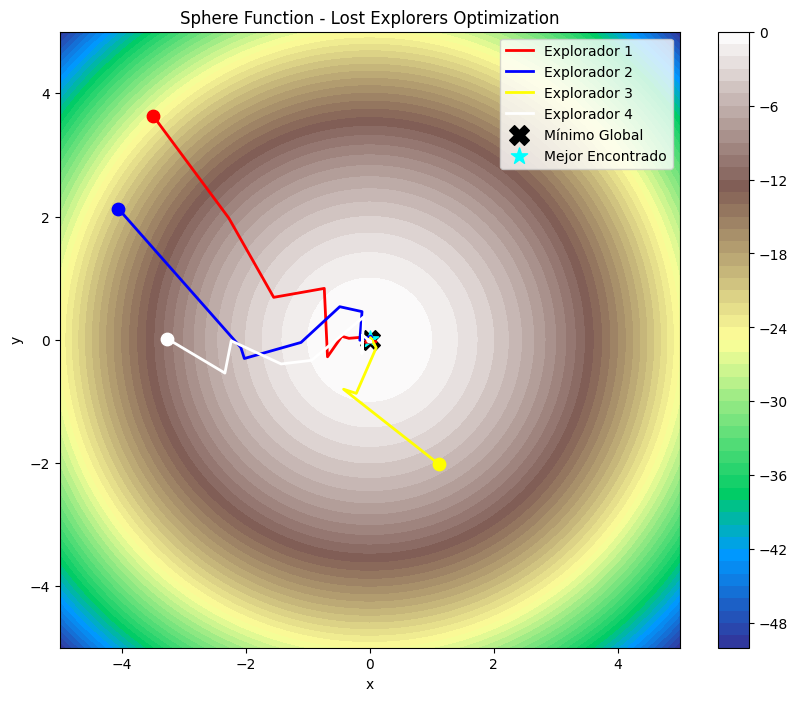

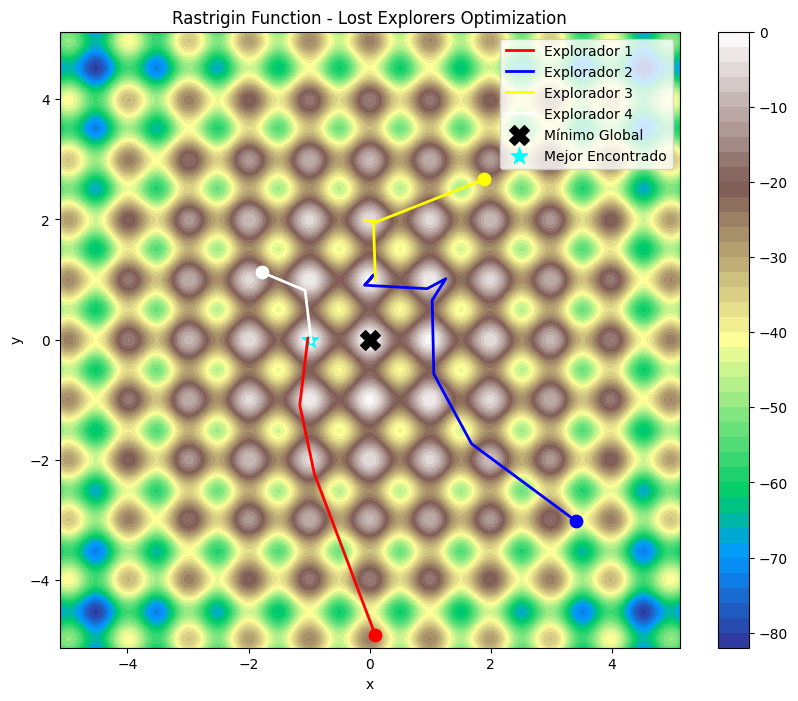

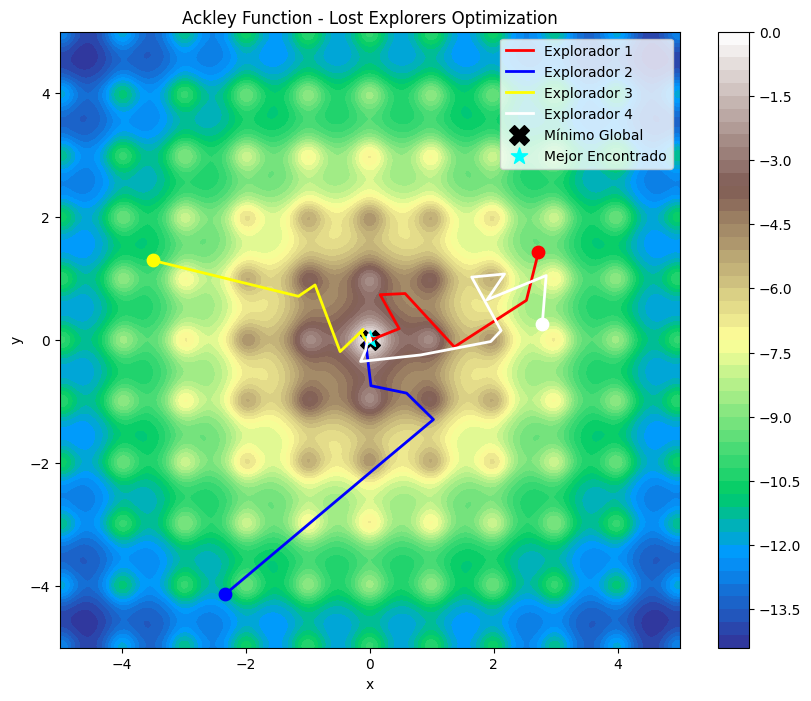

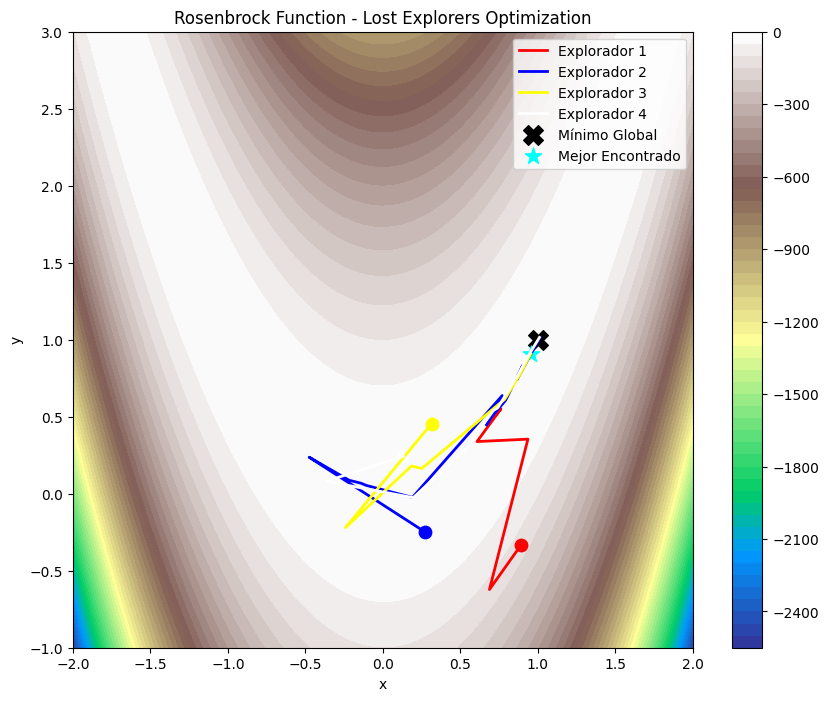

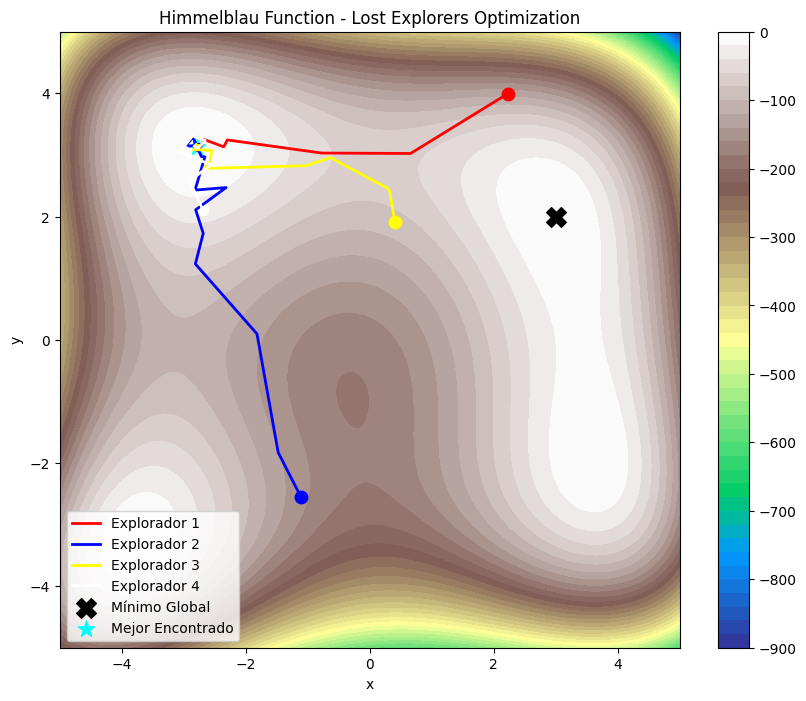

In [24]:
# ============================================================
# CONFIGURACIÓN DE BENCHMARKS
# ============================================================

benchmarks = {
    "Sphere": {
        "function": sphere,
        "bounds": [(-5, 5), (-5, 5)],
        "global_min": (0, 0)
    },
    
    "Rastrigin": {
        "function": rastrigin,
        "bounds": [(-5.12, 5.12), (-5.12, 5.12)],
        "global_min": (0, 0)
    },
    
    "Ackley": {
        "function": ackley,
        "bounds": [(-5, 5), (-5, 5)],
        "global_min": (0, 0)
    },
    
    "Rosenbrock": {
        "function": rosenbrock,
        "bounds": [(-2, 2), (-1, 3)],
        "global_min": (1, 1)
    },
    
    "Himmelblau": {
        "function": himmelblau,
        "bounds": [(-5, 5), (-5, 5)],
        "global_min": (3, 2)
    }
}

# ============================================================
# EJECUTAR BENCHMARKS
# ============================================================

results = {}

for name, benchmark in benchmarks.items():
    
    print("=" * 50)
    print(f"Benchmark: {name}")
    print("=" * 50)
    
    optimizer = LostExplorersOptimization(
        objective_function=benchmark["function"],
        bounds=benchmark["bounds"],
        num_explorers=4
    )
    
    start = time.time()
    
    result = optimizer.optimize()
    
    end = time.time()
    
    results[name] = result
    
    print(f"Mejor posición encontrada: {result['best_position']}")
    print(f"Mejor score encontrado: {result['best_score']:.6f}")
    print(f"Tiempo: {end - start:.4f} segundos")
    
    print()
    


# ============================================================
# VISUALIZACIÓN DE CADA BENCHMARK
# ============================================================

for name, benchmark in benchmarks.items():
    
    f = benchmark["function"]
    bounds = benchmark["bounds"]
    global_min = benchmark["global_min"]
    
    result = results[name]
    
    # --------------------------------------------------------
    # Crear malla
    # --------------------------------------------------------
    
    x = np.linspace(bounds[0][0], bounds[0][1], 300)
    y = np.linspace(bounds[1][0], bounds[1][1], 300)
    
    X, Y = np.meshgrid(x, y)
    
    Z = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f([X[i, j], Y[i, j]])
    
    # ========================================================
    # Gráfica principal
    # ========================================================
    
    plt.figure(figsize=(10, 8))
    
    contour = plt.contourf(
        X,
        Y,
        Z,
        levels=50,
        cmap="terrain"
    )
    
    plt.colorbar(contour)
    
    # --------------------------------------------------------
    # Dibujar trayectorias
    # --------------------------------------------------------
    
    colors = ["red", "blue", "yellow", "white"]
    
    for i, trajectory in enumerate(result["trajectories"]):
        
        trajectory = np.array(trajectory)
        
        plt.plot(
            trajectory[:, 0],
            trajectory[:, 1],
            color=colors[i],
            linewidth=2,
            label=f"Explorador {i+1}"
        )
        
        plt.scatter(
            trajectory[0, 0],
            trajectory[0, 1],
            color=colors[i],
            s=80
        )
    
    # --------------------------------------------------------
    # Mínimo global real
    # --------------------------------------------------------
    
    plt.scatter(
        global_min[0],
        global_min[1],
        color="black",
        s=200,
        marker="X",
        label="Mínimo Global"
    )
    
    # --------------------------------------------------------
    # Mejor solución encontrada
    # --------------------------------------------------------
    
    best = result["best_position"]
    
    plt.scatter(
        best[0],
        best[1],
        color="cyan",
        s=150,
        marker="*",
        label="Mejor Encontrado"
    )
    
    plt.title(f"{name} Function - Lost Explorers Optimization")
    
    plt.xlabel("x")
    plt.ylabel("y")
    
    plt.legend()
    
    plt.show()

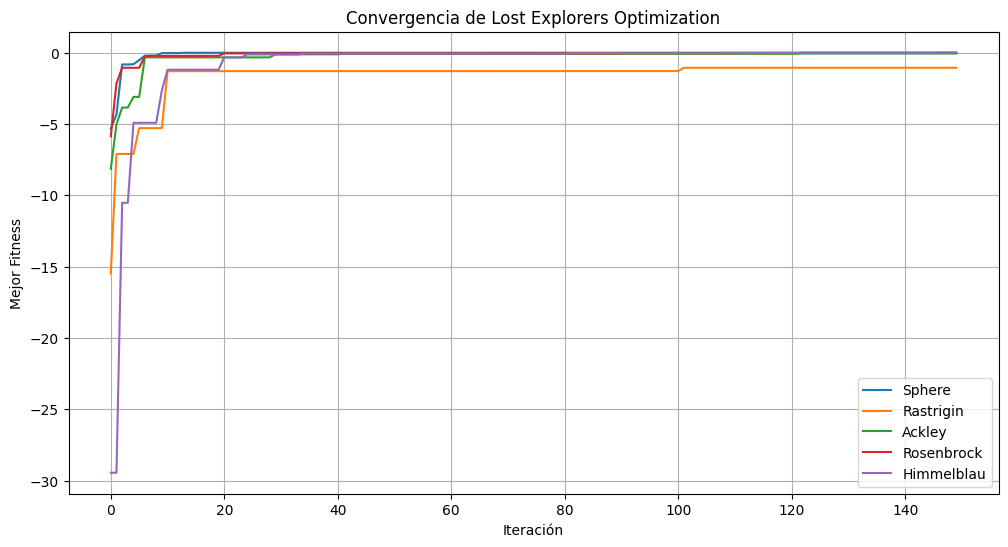

In [25]:
# ============================================================
# COMPARACIÓN DE CONVERGENCIA
# ============================================================

plt.figure(figsize=(12, 6))

for name, result in results.items():
    
    plt.plot(
        result["history"],
        label=name
    )

plt.title("Convergencia de Lost Explorers Optimization")
plt.xlabel("Iteración")
plt.ylabel("Mejor Fitness")

plt.legend()

plt.grid(True)

plt.show()